# Imports

In [1]:
from functions import *

# 1) Dataförståelse & EDA (kort men relevant)

## Load data

In [2]:
df = pd.read_csv("Project/Data/historical_data.csv")

In [3]:
# Get an overview of what the data might look like
display(df.head())

# Check datatypes
df.info()

# Check null values
display(df.isna().sum())

# Show statistical information about data set
display(df.describe())

,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          12000 non-null  int64  
 1   day                         12000 non-null  int64  
 2   event_type                  12000 non-null  object 
 3   category                    12000 non-null  object 
 4   region                      11660 non-null  object 
 5   device                      12000 non-null  object 
 6   account_age_days            12000 non-null  float64
 7   num_prev_listings           12000 non-null  int64  
 8   prev_reports_30d            12000 non-null  int64  
 9   verification_level          12000 non-null  int64  
 10  price                       11182 non-null  float64
 11  num_images                  12000 non-null  int64  
 12  message_length              12000 non-null  int64  
 13  contains_off_platform       120

id                              0
day                             0
event_type                      0
category                        0
region                        340
device                          0
account_age_days                0
num_prev_listings               0
prev_reports_30d                0
verification_level              0
price                         818
num_images                      0
message_length                  0
contains_off_platform           0
urgency_words                   0
payment_attempt                 0
time_to_first_response_min    590
is_suspicious                   0
dtype: int64

,id,day,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11182.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11410.000000,12000.000000
mean,5999.50000,7.482667,99.632567,3.027750,0.151500,0.710167,207.348603,2.870417,111.154417,0.072833,0.099083,0.181167,22.160438,0.102000
std,3464.24595,4.032520,112.903541,1.766467,0.386083,0.719171,196.226023,1.766886,66.396885,0.259874,0.298786,0.385172,28.834047,0.302661
min,0.00000,1.000000,2.200000,0.000000,0.000000,0.000000,7.670000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000,0.000000
25%,2999.75000,4.000000,36.300000,2.000000,0.000000,0.000000,86.195000,2.000000,63.000000,0.000000,0.000000,0.000000,6.700000,0.000000
50%,5999.50000,7.000000,66.600000,3.000000,0.000000,1.000000,149.225000,3.000000,108.000000,0.000000,0.000000,0.000000,13.400000,0.000000
75%,8999.25000,11.000000,120.700000,4.000000,0.000000,1.000000,256.795000,4.000000,155.000000,0.000000,0.000000,0.000000,26.600000,0.000000
max,11999.00000,14.000000,2741.700000,12.000000,3.000000,2.000000,2743.080000,10.000000,416.000000,1.000000,1.000000,1.000000,579.800000,1.000000


## Missing Data
* 340 missing values in `region` — may represent intentionally hidden location information. Considered a less influential feature.
* 818 missing values in `price` — price may be omitted or not yet determined. Considered important because unusual or missing prices could indicate suspicious behavior.
* 590 missing values in `time_to_first_response_min` — may indicate that no response was received. Considered important because response behavior may contain useful signals.

To preserve information about missingness, binary indicator columns were created (missing_region, missing_price, missing_response), where 1 indicates a missing value and 0 indicates a non-missing value. Creating these flags before the train/test split does not introduce leakage because they only describe whether an individual value is missing and do not use information from other samples.

To avoid data leakage, imputation is performed inside the preprocessing pipeline after the train/test split. This ensures that imputation values are learned only from training data and then applied consistently to validation and test data.

Missing values are handled inside the preprocessing pipeline after the train/test split to avoid data leakage.

## Graphs

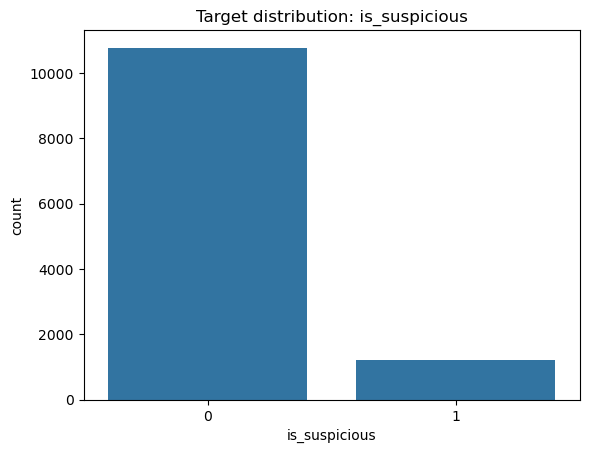

In [4]:
sns.countplot(x=df["is_suspicious"])
plt.title("Target distribution: is_suspicious")
plt.show()

As can be seen, the target class is very imbalanced. There are far more non-suspicous listings than there are suspicous ones.

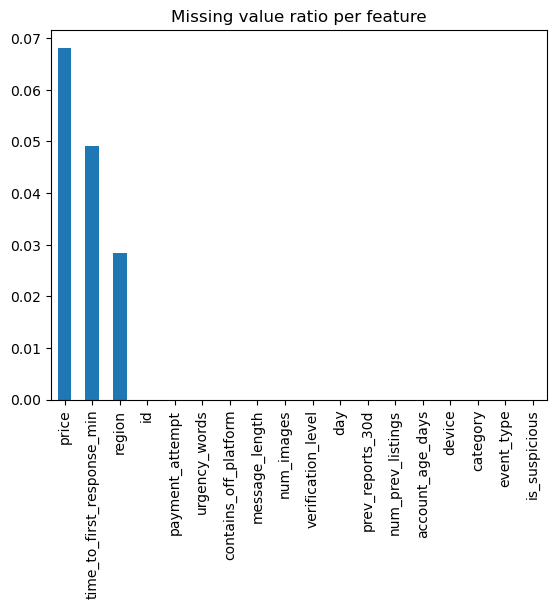

In [5]:
df.isna().mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Missing value ratio per feature")
plt.show()

This graph shows the percentage of missing values in each column. `price` is the most prevailent one, followed by `time_to_response_min` and `region`

# 2) Train/test + preprocessing (korrekt workflow)

In [6]:
# Features
x = df.drop(columns=["is_suspicious", "id"], axis=1)
# Target
y = df["is_suspicious"]

# Add missing flag for all data
x["missing_region"] = x["region"].isna().astype(int)
x["missing_price"] = x["price"].isna().astype(int)
x["missing_response"] = (
    x["time_to_first_response_min"].isna().astype(int)
)

# First split: train + test
x_train_full, x_test, y_train_full, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=r_state
)

# Second split: train + validation
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.25,  # 0.25 of 80% = 20%
    stratify=y_train_full,
    random_state=r_state
)

## Numerical, binary and categories

In [7]:
num_features = [
    "day",
    "account_age_days",
    "num_prev_listings",
    "prev_reports_30d",
    "verification_level",
    "price",
    "num_images",
    "message_length",
    "urgency_words",
    "time_to_first_response_min",
]

binary_features = [
    "contains_off_platform",
    "payment_attempt",
    "missing_region",
    "missing_price",
    "missing_response"
]

cat_features = [
    "event_type",
    "category",
    "region",
    "device"
]

## Transforming, preprocessor pipeline

In [8]:
preprocessor = transform_preprocess(num_features, binary_features, cat_features)

# 3) Modellering och jämförelse

In [9]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=r_state)

# List of models
models = []

# Used to create a dataframe with each models cv and validation scoring
model_results = []

## Model 1 - Baseline

In [10]:
# Pipeline
baseline_model = DummyClassifier(strategy="most_frequent")
models.append(baseline_model)

base_results = evaluate_model("baseline", baseline_model, x_train, y_train, x_val, y_val, cv_strat)
model_results.append(base_results)

Because the dataset is highly imbalanced, the baseline model predicts only the majority class (not suspicious). This results in high accuracy (~90%) while failing to identify suspicious cases. Therefore, accuracy alone is not an appropriate metric. A combination of different metrics will be analyzed from now on.

## Model 2 - Logistic Regression

In [11]:
# Pipeline
log_reg_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear",
        random_state=r_state
    ))
])
models.append(log_reg_model)

log_results = evaluate_model("logistic regression", log_reg_model, x_train, y_train, x_val, y_val, cv_strat)
model_results.append(log_results)

The logistic regression model shows consistent performance across both hold-out validation and cross-validation, indicating stable generalization. However, performance remains moderate, with limited PR-AUC (~0.26–0.29), suggesting that feature representation rather than model complexity is the main limiting factor.

# Model 3 - Random Forest Classifier

In [12]:
# Pipeline
random_forest_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=r_state
    ))
])
models.append(random_forest_model)

rf_results = evaluate_model("random forest classifier", random_forest_model, x_train, y_train, x_val, y_val, cv_strat)
model_results.append(rf_results)

## Comparing models

In [13]:
df_results = pd.DataFrame(model_results)
df_results.sort_values("PR_AUC_CV", ascending=False)

,Model,F1_val,PR_AUC_val,F1_CV,PR_AUC_CV
1,logistic regression,0.292377,0.261997,0.300606,0.292409
2,random forest classifier,0.262023,0.234763,0.295868,0.253781
0,baseline,0.000000,0.102083,0.000000,0.101944


Models were compared using cross-validated PR-AUC as the primary metric because the dataset is imbalanced. Logistic Regression achieved the highest PR-AUC and competitive F1-score, indicating stronger ability to rank suspicious cases while maintaining stable performance across folds. Therefore it was selected as the final model.

# 4) Välj och optimera EN modell (hyperparameter-tuning)

Based on the comparison of models, the logistic regression will be chosen and optimized.

In [14]:
# Parameters to tune
param_grid = {
    "model__C":[0.001,0.01,0.1,1,10,100],
    "model__penalty": ["l1", "l2"]
}

grid = GridSearchCV(
    estimator=log_reg_model,
    param_grid=param_grid,
    cv=cv_strat,
    scoring="average_precision",
    n_jobs=-1
)

grid.fit(x_train, y_train)

# Show the best parameters
print("Best parameters:")
print(grid.best_params_)

# Show best score
print("\nBest CV PR-AUC:")
print(grid.best_score_)

best_log_reg = grid.best_estimator_

Best parameters:
{'model__C': 0.1, 'model__penalty': 'l1'}

Best CV PR-AUC:
0.29496031400159517


In [15]:
y_pred = best_log_reg.predict(x_val)
y_proba = best_log_reg.predict_proba(x_val)[:,1]

print(classification_report(y_val, y_pred))

print(
    "PR-AUC:",
    average_precision_score(y_val, y_proba)
)

              precision    recall  f1-score   support

           0       0.95      0.67      0.78      2155
           1       0.19      0.67      0.29       245

    accuracy                           0.67      2400
   macro avg       0.57      0.67      0.54      2400
weighted avg       0.87      0.67      0.73      2400

PR-AUC: 0.2598932991066102


Hyperparameter tuning was performed using GridSearchCV with stratified cross-validation. The parameters optimized were the regularization strength (C) and regularization type (penalty) of Logistic Regression. The best configuration was C=100 with L2 regularization. However, only marginal improvements were observed compared with the original model. This indicates that the model is relatively insensitive to these hyperparameters and that performance is likely constrained more by the available feature information than by model complexity.

# 5) Threshold / prioritering (kopplat till kravkortet)
The model will use threshold based decision making if a listing is suspicious or not. A range of different thresholds will be tried to determine which makes the most sense for the case.

Shows the most important features used for flagging a listing as suspicious

In [ ]:
importance = extract_feature_coeff(best_log_reg)
display(importance.sort_values("Absolute", ascending=False).head(10))

,Feature,Coefficient,Absolute
10,binary__contains_off_platform,1.334510,1.334510
1,num__account_age_days,-0.672555,0.672555
11,binary__payment_attempt,0.459100,0.459100
4,num__verification_level,-0.434848,0.434848
3,num__prev_reports_30d,0.364695,0.364695
8,num__urgency_words,0.242346,0.242346
29,cat__device_web,-0.136699,0.136699
26,cat__region_urban,-0.107631,0.107631
15,cat__event_type_ad_post,-0.091030,0.091030
7,num__message_length,-0.081485,0.081485


Tries a range of thresholds and one chosen based on Elin's requirements

In [17]:
threshold_results = []

# Probabilities from your chosen model
y_proba = best_log_reg.predict_proba(x_val)[:,1]

# Loop over a range of thresholds
for threshold in np.arange(0.1, 1.0, 0.05):

    # Convert probabilities into predictions
    y_pred = (y_proba >= threshold).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    threshold_results.append({
        "Threshold": round(threshold,2),
        "Precision": precision_score(
            y_val,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_val,
            y_pred,
            zero_division=0
        ),
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn
    })

# Create dataframe
threshold_df = pd.DataFrame(
    threshold_results
)

# Compare results sorting F1 descending
display(
    threshold_df.sort_values(
        "F1",
        ascending=False
    ).reset_index(drop=True)
)

,Threshold,Precision,Recall,F1,FP,FN,TP,TN
0,0.60,0.264108,0.477551,0.340116,326,128,117,1829
1,0.55,0.229508,0.571429,0.327485,470,105,140,1685
2,0.65,0.277955,0.355102,0.311828,226,158,87,1929
3,0.50,0.185017,0.665306,0.289520,718,82,163,1437
4,0.70,0.308411,0.269388,0.287582,148,179,66,2007
5,0.45,0.167417,0.759184,0.274336,925,59,186,1230
6,0.75,0.369565,0.208163,0.266319,87,194,51,2068
7,0.40,0.151400,0.816327,0.255428,1121,45,200,1034
8,0.35,0.139417,0.897959,0.241360,1358,25,220,797
9,0.80,0.423913,0.159184,0.231454,53,206,39,2102


A threshold of 0.60 was selected because the stakeholder prioritizes explainability and minimizing unnecessary impact on legitimate users. While lower thresholds identified more suspicious cases, they also produced substantially more false positives. At a threshold of 0.60, the model achieved the highest F1-score (0.34) while reducing false positives to 326 cases, compared with 718 at the default threshold of 0.50 and 1566 at a threshold of 0.30.

Flagged listings are not immediately removed. Instead, they are sent for manual review. This policy reduces the risk of unfair actions against legitimate users while maintaining a consistent and explainable process.

The most important features used in decision making are:
* contains_off_platform
* account_age_days
* payment_attempt
* verification_level
* prev_reports_30d

An example of a suspicious listing could look like:
* A listing from a newly created account with previous reports and attempts to move communication or payment outside the platform may receive a higher risk score and therefore be sent for manual review.

Listings are flagged based on a combination of multiple signals. A single suspicious indicator does not necessarily lead to a flag, but several risk indicators together increase the probability of a listing being considered suspicious.